PROYECTO PARCIAL:
Reporte sobre la calidadde un Dataset

Pérez Ramírez Paola Guadalupe -
22110143

Importar bibliotecas

In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
import time

Leer el dataset

In [2]:
df = pd.read_csv('Road_Accident_Data.csv')
df2 = pd.read_csv("Road_Accident_Data.csv")

Verificar columnas del dataset

In [3]:
df.head()

,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


Información genereal del dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  object 
 1   Accident Date               307973 non-null  object 
 2   Month                       307973 non-null  object 
 3   Day_of_Week                 307973 non-null  object 
 4   Year                        307973 non-null  int64  
 5   Junction_Control            307973 non-null  object 
 6   Junction_Detail             307973 non-null  object 
 7   Accident_Severity           307973 non-null  object 
 8   Latitude                    307973 non-null  float64
 9   Light_Conditions            307973 non-null  object 
 10  Local_Authority_(District)  307973 non-null  object 
 11  Carriageway_Hazards         5424 non-null    object 
 12  Longitude                   307973 non-null  float64
 13  Number_of_Casu

Verificar tipo de datos

In [5]:
print(df.dtypes)

Accident_Index                 object
Accident Date                  object
Month                          object
Day_of_Week                    object
Year                            int64
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object


Estadística descriptiva antes de la limpieza

In [6]:
print(df.describe())

                Year       Latitude      Longitude  Number_of_Casualties  \
count  307973.000000  307973.000000  307973.000000         307973.000000   
mean     2021.468934      52.487005      -1.368884              1.356882   
std         0.499035       1.339011       1.356092              0.815857   
min      2021.000000      49.914488      -7.516225              1.000000   
25%      2021.000000      51.485248      -2.247937              1.000000   
50%      2021.000000      52.225943      -1.349258              1.000000   
75%      2022.000000      53.415517      -0.206810              1.000000   
max      2022.000000      60.598055       1.759398             48.000000   

       Number_of_Vehicles    Speed_limit  
count       307973.000000  307973.000000  
mean             1.829063      38.866037  
std              0.710477      14.032933  
min              1.000000      10.000000  
25%              1.000000      30.000000  
50%              2.000000      30.000000  
75%           

Valores nulos y porcentaje de valores faltantes

In [7]:
missing_data = df.isnull().sum()
missing_porcentage = (missing_data / len(df)) * 100
missing_porcentage = missing_porcentage.round(2)

missing_info = pd.DataFrame({
    'Valores nulos: ': missing_data, 
    'Porcentaje: ': missing_porcentage.astype(str) + '%'})

print(missing_info)

                            Valores nulos:  Porcentaje: 
Accident_Index                            0         0.0%
Accident Date                             0         0.0%
Month                                     0         0.0%
Day_of_Week                               0         0.0%
Year                                      0         0.0%
Junction_Control                          0         0.0%
Junction_Detail                           0         0.0%
Accident_Severity                         0         0.0%
Latitude                                  0         0.0%
Light_Conditions                          0         0.0%
Local_Authority_(District)                0         0.0%
Carriageway_Hazards                  302549       98.24%
Longitude                                 0         0.0%
Number_of_Casualties                      0         0.0%
Number_of_Vehicles                        0         0.0%
Police_Force                              0         0.0%
Road_Surface_Conditions        

Detectar datos duplicados

In [8]:
print(f'Cantidad de duplicados: {df.duplicated().sum()}')

Cantidad de duplicados: 1


Eliminar o consolidar valores duplicados

In [9]:
df.drop_duplicates(inplace=True)

Imputación de valores faltantes 

In [10]:
df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

Eliminar filas con valores nulos

In [11]:
df.dropna(subset=['Accident_Index', 'Accident Date', 'Time'], inplace=True)

Valores atípicos (análisis estadístico y visualizaciones (boxplots, histogramas))

LIMITE DE VELOCIDAD

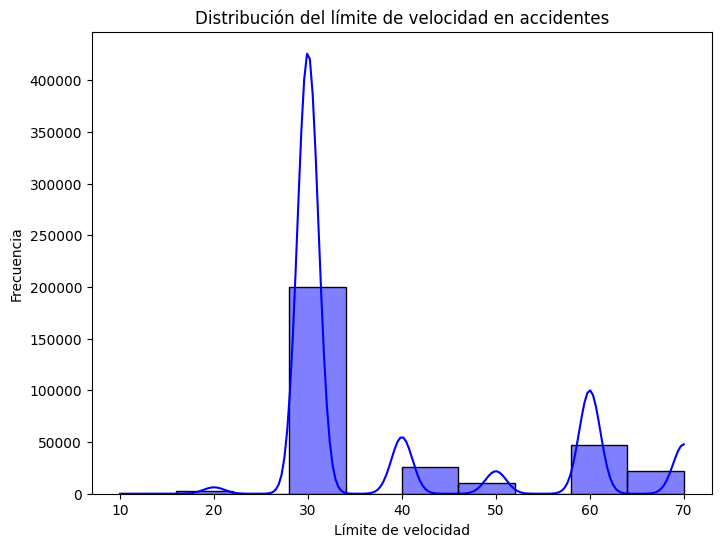

In [12]:
plt.figure(figsize=(8,6))
sns.histplot(df['Speed_limit'], bins=10, kde=True, color='blue')
plt.title('Distribución del límite de velocidad en accidentes')
plt.xlabel('Límite de velocidad')
plt.ylabel('Frecuencia')
plt.show()

NÚMERO DE VICTIMAS

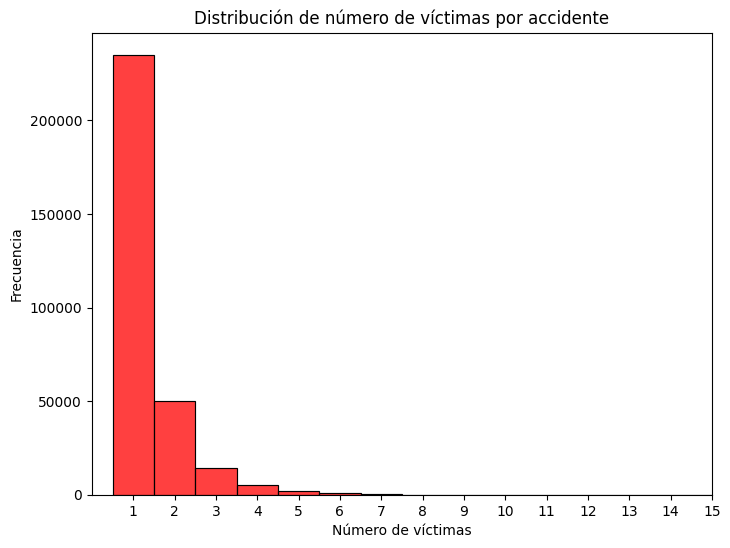

In [13]:
plt.figure(figsize=(8,6))
sns.histplot(df['Number_of_Casualties'], bins=20, color='red', discrete=True)
plt.title('Distribución de número de víctimas por accidente')
plt.xlabel('Número de víctimas')
plt.ylabel('Frecuencia')
plt.xlim(0, 15) 
plt.xticks(range(1, 16)) 
plt.show()


HORA DE ACCIDENTE

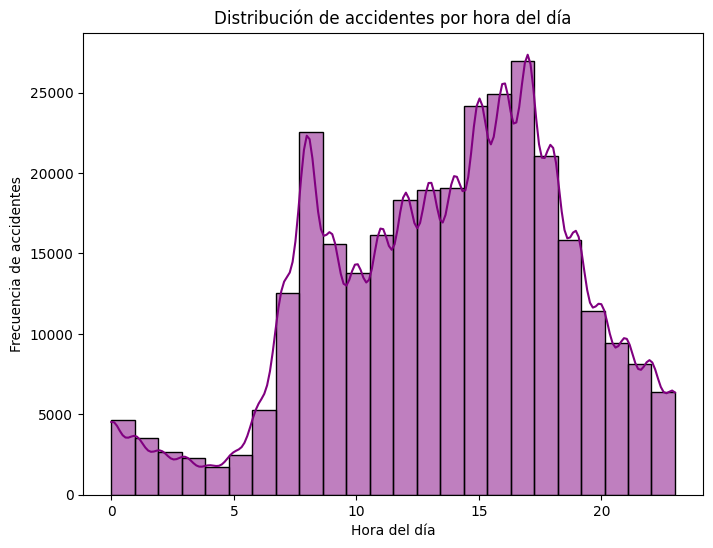

In [14]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour

plt.figure(figsize=(8,6))
sns.histplot(df['Hour'], bins=24, kde=True, color='purple')
plt.title('Distribución de accidentes por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Frecuencia de accidentes')
plt.show()

Eliminación de outliers

In [15]:
numeric_cols = df.select_dtypes(include=['number']).columns  

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1  

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[~((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)]

print(f'Antes de eliminar outliers: {df.shape[0]}')
print(f'Después de eliminar outliers: {df_cleaned.shape[0]}')

Antes de eliminar outliers: 307972
Después de eliminar outliers: 229118


Convertir formatos de datos incorrectos y normalizar las variables 

In [16]:
df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce')
df['Day_of_Week'] = df['Day_of_Week'].astype('category')

Estadísticas descriptiva después de la limpieza

In [17]:
print(df.describe())

                       Accident Date           Year       Latitude  \
count                         307972  307972.000000  307972.000000   
mean   2021-12-23 22:21:18.537009664    2021.468935      52.487001   
min              2021-01-01 00:00:00    2021.000000      49.914488   
25%              2021-06-28 00:00:00    2021.000000      51.485248   
50%              2021-12-08 00:00:00    2021.000000      52.225935   
75%              2022-06-25 00:00:00    2022.000000      53.415514   
max              2022-12-31 00:00:00    2022.000000      60.598055   
std                              NaN       0.499035       1.339011   

           Longitude  Number_of_Casualties  Number_of_Vehicles    Speed_limit  \
count  307972.000000         307972.000000       307972.000000  307972.000000   
mean       -1.368882              1.356883            1.829066      38.866001   
min        -7.516225              1.000000            1.000000      10.000000   
25%        -2.247942              1.000000   

Inferencias

ACCIDENTES POR CONDICIONES CLIMÁTICAS

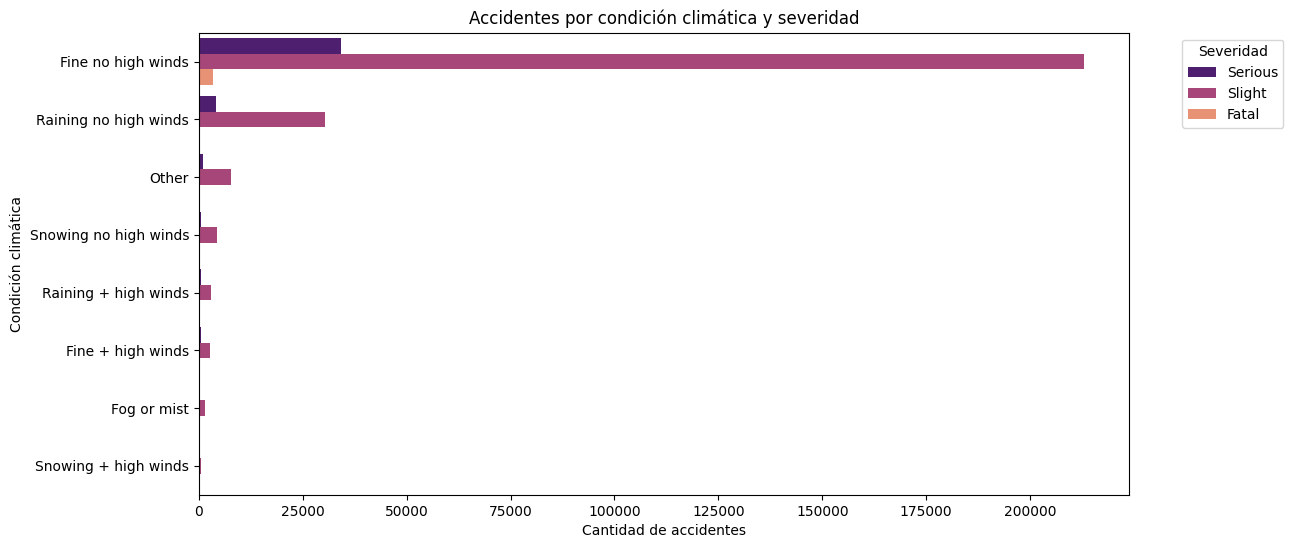

In [18]:
plt.figure(figsize=(12,6))
sns.countplot(y='Weather_Conditions', hue='Accident_Severity', data=df, palette='magma', order=df['Weather_Conditions'].value_counts().index)
plt.title('Accidentes por condición climática y severidad')
plt.xlabel('Cantidad de accidentes')
plt.ylabel('Condición climática')
plt.legend(title='Severidad', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

ACCIDENTES POR LIMITES DE VELOCIDAD

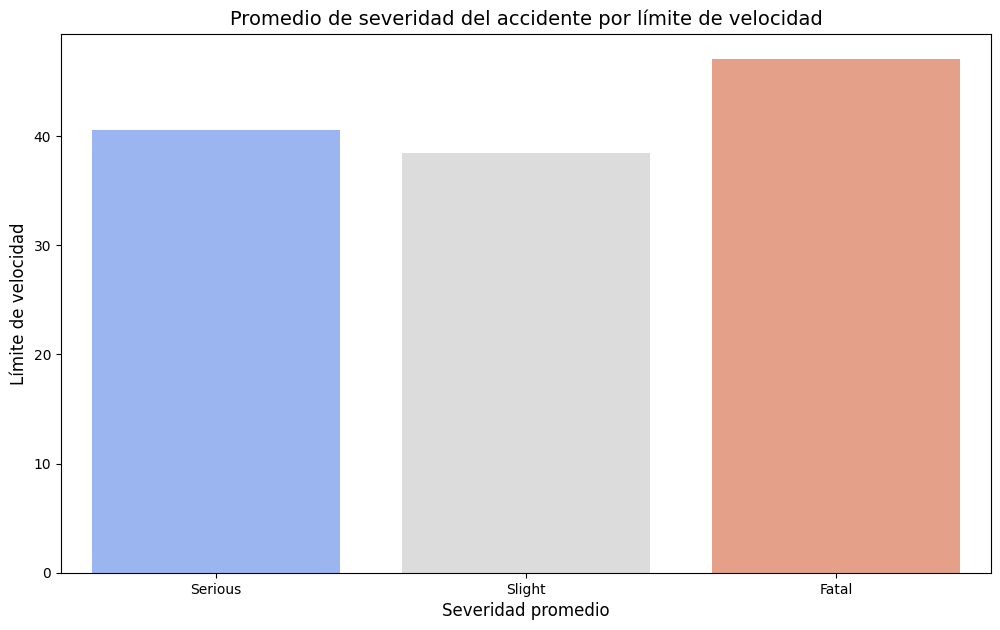

In [19]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Accident_Severity', y='Speed_limit', data=df, errorbar=None, palette='coolwarm', hue='Accident_Severity')

plt.title('Promedio de severidad del accidente por límite de velocidad', fontsize=14)
plt.xlabel('Severidad promedio', fontsize=12)
plt.ylabel('Límite de velocidad', fontsize=12)
plt.show()

DISPERSIÓN ENTRE NÚMEROS DE VEHICULOS Y NÚMERO DE VÍCTIMAS

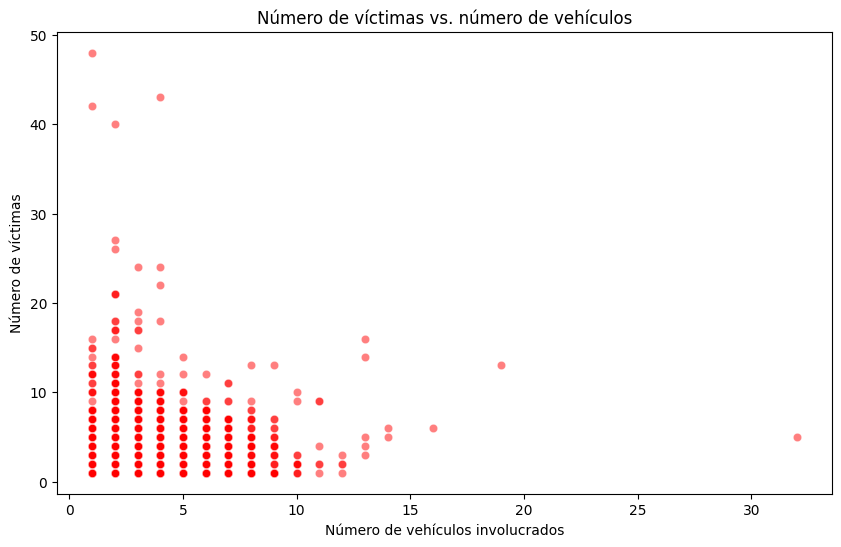

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Number_of_Vehicles', y='Number_of_Casualties', data=df, alpha=0.5, color='red')
plt.title('Número de víctimas vs. número de vehículos')
plt.xlabel('Número de vehículos involucrados')
plt.ylabel('Número de víctimas')
plt.show()

ACCIDENTES EN ZONAS URBANAS VS RURALES

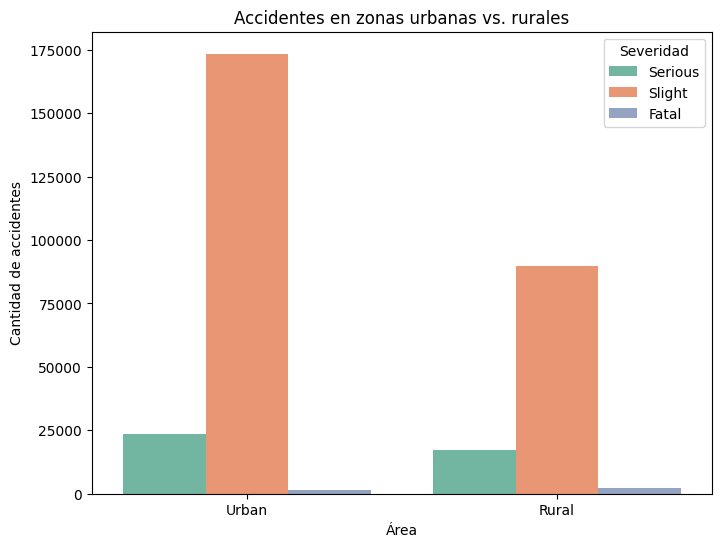

In [21]:
plt.figure(figsize=(8,6))
sns.countplot(x='Urban_or_Rural_Area', hue='Accident_Severity', data=df, palette='Set2')
plt.title('Accidentes en zonas urbanas vs. rurales')
plt.xlabel('Área')
plt.ylabel('Cantidad de accidentes')
plt.legend(title='Severidad')
plt.show()


Cambios de calidad

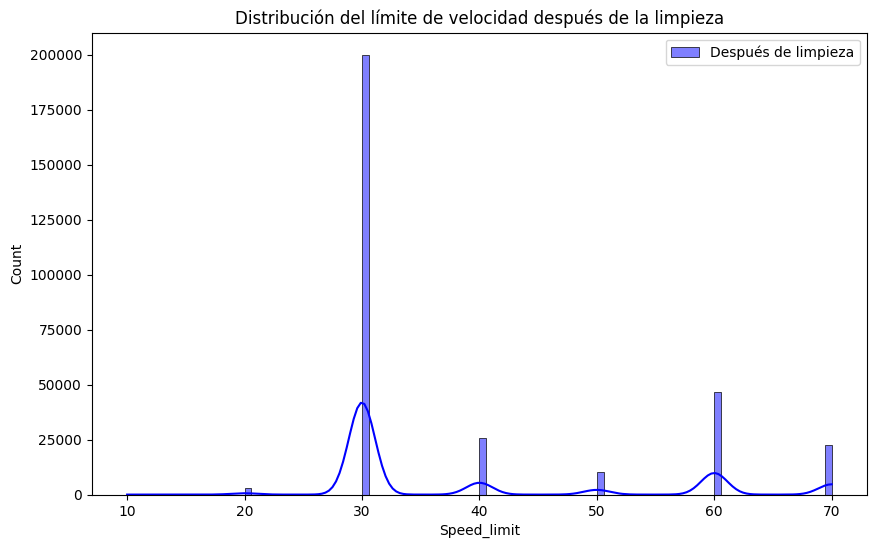

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df['Speed_limit'], kde=True, color='blue', label='Después de limpieza')
plt.legend()
plt.title('Distribución del límite de velocidad después de la limpieza')
plt.show()

Comparación de valores nulos

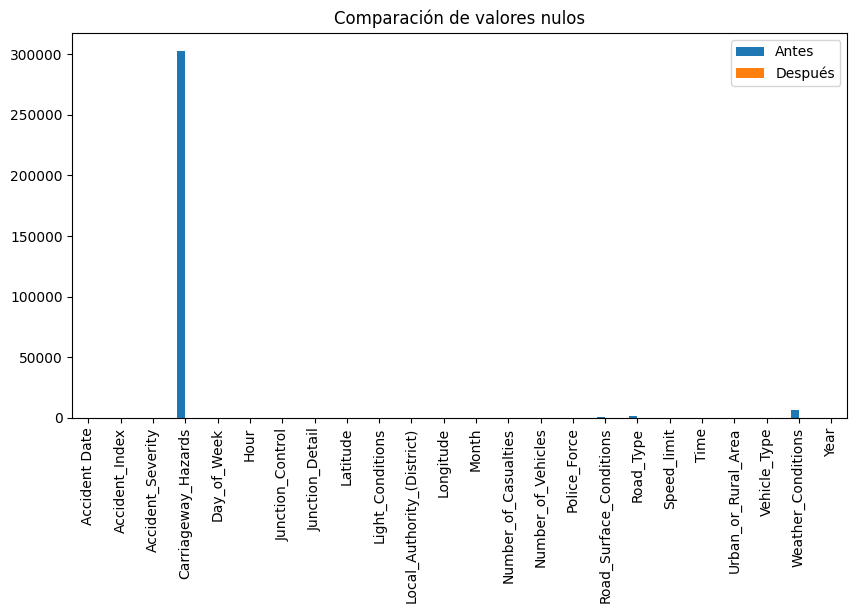

In [23]:
null_counts = pd.DataFrame({
    "Antes": df2.isnull().sum(), #antes de limpieza
    "Después": df.isnull().sum() #despues de limpieza

})
null_counts.plot(kind="bar", figsize=(10, 5), title="Comparación de valores nulos")
plt.show()

Comparación de duplicados 

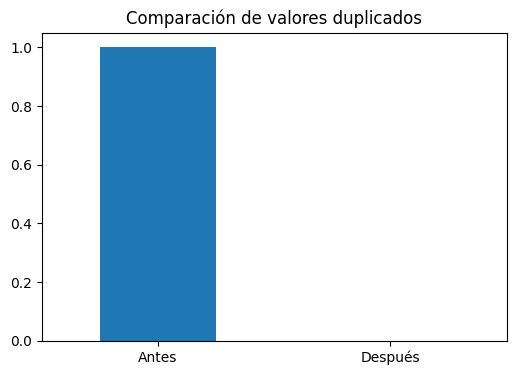

In [24]:
duplicates = pd.DataFrame({
    "Antes": [df2.duplicated().sum()], #antes de limpieza
    "Después": [df.duplicated().sum()], #despues de limpieza
})
duplicates.T.plot(kind="bar", figsize=(6, 4), title="Comparación de valores duplicados", legend=False)
plt.xticks(rotation=0)
plt.show()

Comparación de número de columnas

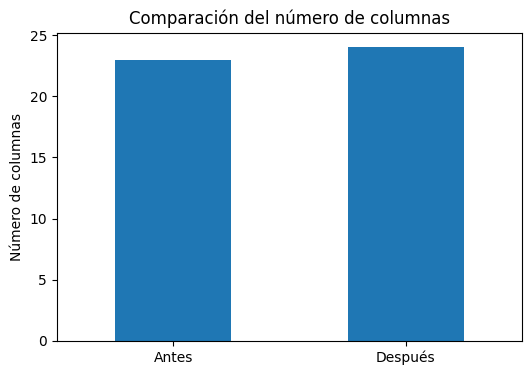

In [25]:
columns_count = pd.DataFrame({
    "Antes": [df2.shape[1]], #antes de limpieza
    "Después": [df.shape[1]], #despues de limpieza
})
columns_count.T.plot(kind="bar", figsize=(6, 4), title="Comparación del número de columnas", legend=False)

plt.xticks(rotation=0)
plt.ylabel("Número de columnas")
plt.show()

Recomendaciones:

- Manejo de valores faltantes: Implementar validaciones en el sistema de recopilación para que no falten datos importantes y utilizar métodos de imputación si los valores faltantes no pueden evitarse.
- Control de duplicados: Establecer verificaciones automáticas durante la entrada de datos para evitar duplicados e implementar alertas para notificar a los usuarios si un dato ya existe.
- Tratamiento de outliers: Monitorear y validar la presencia de outliers antes de eliminar o ajustar.
- Mejoras en la recolección de datos: Automatizar el registro de datos e implementar validaciones en tiempo real para tener coherencia de los datos ingresados.
- Monitoreo y mantenimiento continuo: Realizar auditorías periódicas del dataset para detectar problemas de calidad y mantener un historial de cambios en los datos para facilitar auditorías futuras.
- Estandarización de formatos: Asegurar que los datos se ingresen en formatos estandarizados para evitar inconsistencias

Hallazgos:
- Valores faltantes: Este dataset, tenia valores nulos que se imputaron con la media (para columnas numéricas) y la moda (para columnas categóricas), lo que podría tener problemas en la recopilación de datos.
- Duplicados: En este dataset había varios duplicados, los cuales fueron eliminados para evitar sesgar los análisis.
- Outliers: Se encontraron outliers, que podían distorsionar los resultados.

 Estrategias de limpieza aplicadas:

- Manejo de valores faltantes: Se imputaron los valores faltantes con la media para columnas numéricas y la moda para columnas categóricas y elimine filas con valores faltantes en columnas críticas.
- Eliminación de duplicados: Identifique y elimine los registros duplicados para mejorar la precisión de los datos.
- Tratamiento de outliers: Localice y elimine outliers utilizando el rango intercuartílico (IQR).
- Conversión de formatos de datos: Estandarice el formato de la fecha en Accident Date y convertí Day_of_Week a tipo categoría.
- Generación de Nuevas Variables: Obtuve la hora de la columna Time para analizar la distribución temporal de los accidentes.

CONCLUSIÓN:

El análisis de este dataset permitió evaluar la calidad de los datos, hacer una limpieza efectiva y extraer información importante sobre los accidentes de tránsito. Se identificaron los datos faltantes, valores atípicos y registros duplicados, lo que permitio aplicar estrategias para mejorar la inofromación del dataset.
Despues de la limpieza, los datos obtuvieron una mejor estructura y mayor confiabilidad, lo que permitio hacer inferencias más precisas, como la ocurrencia y severidad de los accidentes, la influencia de factores como el límite de velocidad, la hora del día, las condiciones climáticas y la ubicación del accidente.

Este proceso facilitó un análisis más preciso y también demostró la importancia de un tratamiento adecuado de los datos antes de realizar cualquier interpretación o toma de decisiones, garantizando la calidad de los datos, y así obtener información útil y aplicable para mejorar la seguridad vial y desarrollar estrategias de prevención de accidentes. 